# <center>**LastFM Data Science Project**</center>

## **Import Libraries**

In [3]:
import pylast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from bs4 import BeautifulSoup
import requests
from sklearn.preprocessing import MultiLabelBinarizer

# **Data Preparation**

## **Get API Access**

In [6]:
API_KEY = "2d901b318bd2a5c736ca66d22eadf0ae"
API_SECRET = "daa7b060a8bee7f17c7ba9f88d2f535f"
network = pylast.LastFMNetwork(
    api_key=API_KEY,
    api_secret=API_SECRET
)

# test connection
user = network.get_user('cosmeticstm')
print(user.get_name())

cosmeticstm


## **Get dynamic threshold for limit parameter**

In [8]:
def get_dynamic_threshold(user, fetch_limit=1000, percentile=75):
    '''
    Set threshold at the nth percentile of play counts
    '''
    import numpy as np
    
    top_artists = user.get_top_artists(limit=fetch_limit)
    play_counts = [int(a.weight) for a in top_artists]
    
    threshold = int(np.percentile(play_counts, percentile))
    print(f"Dynamic threshold ({percentile}th percentile): {threshold} plays")
    
    meaningful = [a for a in top_artists if int(a.weight) >= threshold]
    print(f"Artists above threshold: {len(meaningful)}")
    
    return meaningful

play_count = get_dynamic_threshold(user)

Dynamic threshold (75th percentile): 88 plays
Artists above threshold: 255


**Insights:**



## **Get top artists**

In [11]:
def fetch_artist_data(artist):
    '''Fetch data for a single artist, including tags.'''
    try:
        tags = artist.item.get_top_tags(limit=15) # set to any limit
        tag_names = [tag.item.name.lower() for tag in tags]
    except pylast.WSError as e:
        print(f"Could not fetch tags for '{artist.item.name}': {e}")
        tag_names = []

    return {
        'artist_name': artist.item.name,
        'play_count': int(artist.weight),
        'url': artist.item.get_url(),
        'tags': tag_names
    }

def parse_top_artists(top_artists, max_workers=10):
    '''
    Convert top artists to DataFrame format, including top tags.
    Fetches tags concurrently to reduce runtime.
    '''
    results = [None] * len(top_artists)  # preserve order

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_index = {
            executor.submit(fetch_artist_data, artist): i
            for i, artist in enumerate(top_artists)
        }
        for future in as_completed(future_to_index):
            i = future_to_index[future]
            results[i] = future.result()

    return pd.DataFrame(results)

# Usage
top_artists = user.get_top_artists(limit=len(play_count))
artists_df = parse_top_artists(top_artists, max_workers=10)
print(artists_df.head())
print(f'Dataframe Shape: {artists_df.shape}')

     artist_name  play_count                                         url  \
0     Kanye West        7070      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6400  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5850   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4577            https://www.last.fm/music/bladee   
4          Lucki        4206             https://www.last.fm/music/lucki   

                                                tags  
0  [hip-hop, rap, hip hop, rnb, kanye west, gay f...  
1  [trap, hip-hop, rap, emo rap, pop rap, hip hop...  
2  [trap, cloud rap, hip-hop, rap, rage, hip hop,...  
3  [cloud rap, trap, drain, hip-hop, hip hop, emo...  
4  [pop, dance, lucki, swedish, trap, female voca...  
Dataframe Shape: (255, 4)


# **Data Preprocessing**

## **Scrape list of valid tags / genres from MusicBrainz.org**

In [14]:
url = 'https://musicbrainz.org/genres' # URL to be scraped
page = requests.get(url) # use requests library

soup = BeautifulSoup(page.text, 'html') # use BS to read html

In [15]:
# remove comments from genres
for comment in soup.find_all('span', class_='comment'):
    comment.decompose()

genres = soup.find_all('bdi') # find all <bdi> tags 

valid_genres = set(genre.text.lower().strip() for genre in genres)

## **Filter valid genres with tags df** 

In [17]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag in valid_genres]
)
print(artists_df.head())

     artist_name  play_count                                         url  \
0     Kanye West        7070      https://www.last.fm/music/kanye%2bwest   
1   Lil Uzi Vert        6400  https://www.last.fm/music/lil%2buzi%2bvert   
2  Playboi Carti        5850   https://www.last.fm/music/playboi%2bcarti   
3         Bladee        4577            https://www.last.fm/music/bladee   
4          Lucki        4206             https://www.last.fm/music/lucki   

                                            tags  
0                     [hip hop, pop, electronic]  
1   [trap, emo rap, pop rap, hip hop, cloud rap]  
2        [trap, cloud rap, rage, hip hop, plugg]  
3  [cloud rap, trap, hip hop, emo rap, hyperpop]  
4          [pop, dance, trap, techno, cloud rap]  


## **Check for null tags**

In [19]:
null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(null_tags)
print(f'\nNumber of null tags / genres: {num_null_tags}')

                     artist_name  play_count  \
82                alex_g_offline         347   
111               jaydes archive         273   
151                       yenny*         177   
165                 alexgoffline         161   
195               Ligaya Escueta         127   
220                     Kimaurii         105   
252  Lil Uzi Vert, Playboi Carti          88   

                                                   url tags  
82            https://www.last.fm/music/alex_g_offline   []  
111         https://www.last.fm/music/jaydes%2barchive   []  
151               https://www.last.fm/music/yenny%252a   []  
165             https://www.last.fm/music/alexgoffline   []  
195         https://www.last.fm/music/ligaya%2bescueta   []  
220                 https://www.last.fm/music/kimaurii   []  
252  https://www.last.fm/music/lil%2buzi%2bvert%252...   []  

Number of null tags / genres: 7


**Insights:**
- I decided to drop the 7 artists with null tags since `alex_g_offline`, `alexgoffline`, `jaydes archive`, and `yenny*` are unofficial archival accounts, not real artists
- `Ligaya Escueta` and `Kimaurii` are niche artists that didn't have any tag data, and thus won't contribute anything meaningfully to ML.
- `Lil Uzi Vert, Playboi Carti` are artifacts that came from Spotify Local Files scrobbling.

### **Prune null tags**

In [22]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (248, 4)


## **Check for sparse tags**

In [24]:
all_tags = [tag for tags in artists_df['tags'] for tag in tags] # Loops to find each tag in tags column

tag_series = pd.Series(all_tags) # Converts into series
tag_counts = tag_series.value_counts() # Counts how many times tag appears

sparse_tags = set(tag_counts[tag_counts < 5].index)
print(sparse_tags)

{'2-step', 'chillout', 'jangle pop', 'techno', 'regalia', 'post-punk revival', 'instrumental', 'instrumental hip hop', 'funk rock', 'baltimore club', 'future bass', 'krautrock', 'conscious hip hop', 'abstract hip hop', 'boom bap', 'jazz rap', 'glitch pop', 'noise rock', 'sigilkore', 'trip hop', 'powerviolence', 'minimal synth', 'futurepop', 'opm', 'dark plugg', 'dirty south', 'k-pop', 'djent', 'jazz', 'mathcore', 'city pop', 'indietronica', 'gothic rock', 'rave', 'country', 'dubstep', 'gothic', 'melodic death metal', 'space rock', 'house', 'rap metal', 'euro-trance', 'depressive black metal', 'americana', 'drill', 'britpop', 'tarantella', 'stoner rock', 'electro', 'garage rock revival', 'neo-psychedelia', 'shibuya-kei', 'glitch', 'horror punk', 'hypnagogic pop', 'avant-garde jazz', 'downtempo', 'ethereal wave', 'death metal', 'dance', 'ambient americana', 'folk punk', 'funk metal', 'wave', 'j-rock', 'drum and bass', 'hyperpop', 'uk hardcore', 'electropop', 'new rave', 'free jazz', 'sop

### **Remove sparse tags and check null tags**

In [26]:
artists_df['tags'] = artists_df['tags'].apply(
    lambda tags: [tag for tag in tags if tag not in sparse_tags]
) # Checks if tag is not in sparse_tags

print(artists_df[artists_df['tags'].apply(len) == 0]) # Checks artists with null tags

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {num_null_tags}')

    artist_name  play_count                             url tags
210        Yuke         110  https://www.last.fm/music/yuke   []
Number of null tags / genres: 1


### **Remove null tags**

In [28]:
artists_df = artists_df[artists_df['tags'].apply(len) > 0].reset_index(drop=True)

null_tags = artists_df[artists_df['tags'].str.len() == 0]
num_null_tags = len(null_tags)

print(f'Number of null tags / genres: {len(null_tags)}')
print(f'Dataframe Shape: {artists_df.shape}')

Number of null tags / genres: 0
Dataframe Shape: (247, 4)


## **Feature Engineering**

In [30]:
mlb = MultiLabelBinarizer()
ohe = pd.DataFrame(
    mlb.fit_transform(artists_df['tags']),
    columns=mlb.classes_,
    index=artists_df.index
)

final_df = pd.concat([artists_df, ohe], axis=1)
final_df = final_df.drop('tags', axis=1)
print(f'Final Dataframe Shape: {final_df.shape}')
print(f'Columns:\n{final_df.columns}')

Final Dataframe Shape: (247, 57)
Columns:
Index(['artist_name', 'play_count', 'url', 'alternative metal',
       'alternative rock', 'ambient', 'art pop', 'bedroom pop', 'cloud rap',
       'dream pop', 'electronic', 'emo', 'emo rap', 'emocore', 'experimental',
       'experimental hip hop', 'folk', 'funk', 'gangsta rap', 'grunge',
       'hard rock', 'hardcore punk', 'hip hop', 'horrorcore', 'indie folk',
       'indie pop', 'indie rock', 'lo-fi', 'math rock', 'melodic hardcore',
       'metal', 'metalcore', 'midwest emo', 'noise pop', 'nu metal', 'plugg',
       'pluggnb', 'pop', 'pop punk', 'pop rap', 'pop rock', 'post-hardcore',
       'post-punk', 'post-rock', 'psychedelic', 'punk', 'punk rock', 'rage',
       'rock', 'screamo', 'shoegaze', 'singer-songwriter', 'slacker rock',
       'slowcore', 'soul', 'southern hip hop', 'trap'],
      dtype='str')


# **Exploratory Data Analysis (EDA)**

## **Play Count Distribution**

=== Descriptive Statistics ===
Total artists: 247
Max plays: 7070
Min plays: 88
Median plays: 233
Mean plays: 528.09
Std dev: 907.31


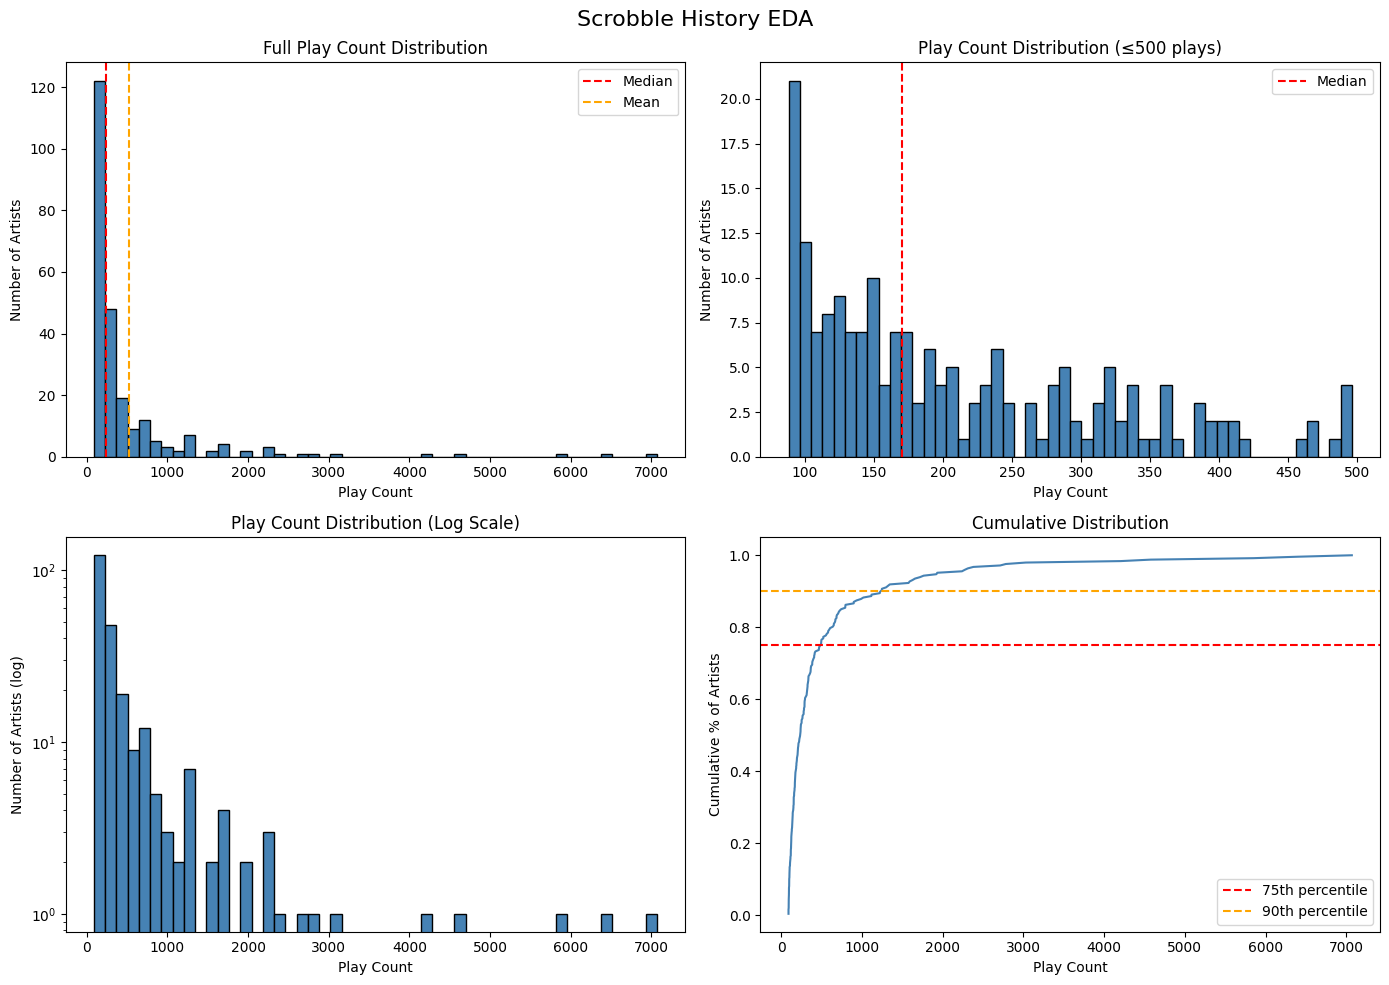

Total artists that exceed 1000: 30


In [33]:
play_counts = artists_df['play_count'].tolist()

# Basic stats
print("=== Descriptive Statistics ===")
print(f"Total artists: {len(play_counts)}")
print(f"Max plays: {max(play_counts)}")
print(f"Min plays: {min(play_counts)}")
print(f"Median plays: {int(np.median(play_counts))}")
print(f"Mean plays: {np.mean(play_counts):.2f}")
print(f"Std dev: {np.std(play_counts):.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scrobble History EDA', fontsize=16)

# 1. Full distribution
axes[0,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Full Play Count Distribution')
axes[0,0].set_xlabel('Play Count')
axes[0,0].set_ylabel('Number of Artists')
axes[0,0].axvline(np.median(play_counts), color='red', linestyle='--', label='Median')
axes[0,0].axvline(np.mean(play_counts), color='orange', linestyle='--', label='Mean')
axes[0,0].legend()

# 2. Zoomed in
zoomed = [p for p in play_counts if p <= 500]
axes[0,1].hist(zoomed, bins=50, color='steelblue', edgecolor='black')
axes[0,1].set_title('Play Count Distribution (≤500 plays)')
axes[0,1].set_xlabel('Play Count')
axes[0,1].set_ylabel('Number of Artists')
axes[0,1].axvline(np.median(zoomed), color='red', linestyle='--', label='Median')
axes[0,1].legend()

# 3. Log scale distribution
axes[1,0].hist(play_counts, bins=50, color='steelblue', edgecolor='black', log=True)
axes[1,0].set_title('Play Count Distribution (Log Scale)')
axes[1,0].set_xlabel('Play Count')
axes[1,0].set_ylabel('Number of Artists (log)')

# 4. Cumulative distribution
sorted_counts = np.sort(play_counts)
cumulative = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1,1].plot(sorted_counts, cumulative, color='steelblue')
axes[1,1].set_title('Cumulative Distribution')
axes[1,1].set_xlabel('Play Count')
axes[1,1].set_ylabel('Cumulative % of Artists')
axes[1,1].axhline(0.75, color='red', linestyle='--', label='75th percentile')
axes[1,1].axhline(0.90, color='orange', linestyle='--', label='90th percentile')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f'Total artists that exceed 1000: {(artists_df['play_count'] > 1000).sum()}')  # how many exceed 1000

**Insights:**
- The play count distribution shows that scrobbles (aka plays / listens) are heavily right-skewed, meaning a large majority of artists recorded in my LastFM listening history have less than ~1000 total listens.
    - The mean and median of play counts further show that a large portion of the artists is densely focused between the <1000 listens area which further confirm my hypothesis.
    - For a listening distribtion, this is normal since only a few artists would tend to be listened to repeatedly (hardcore faves), while a majority of other artists would have listens on the smaller end (casual - occasional listens).
- Zoomed in play count distribution shows that most artists only have ~100 total artists, slowly tapering off until the 500 total listens mark.
    -   Artists with $\small \leq$100 listens can be classified as 'accidental' listens
- Based on the log scaled distribution, artists that have more than 1000 total listens are sparse in the dataset.
    - The cumulative distribution indicates that 75% of artists have less than 1000 listens (~185 artists) while 90% of artists have less than ~1500 listens (~222 artists).

## **Tag / Genre Distribution**

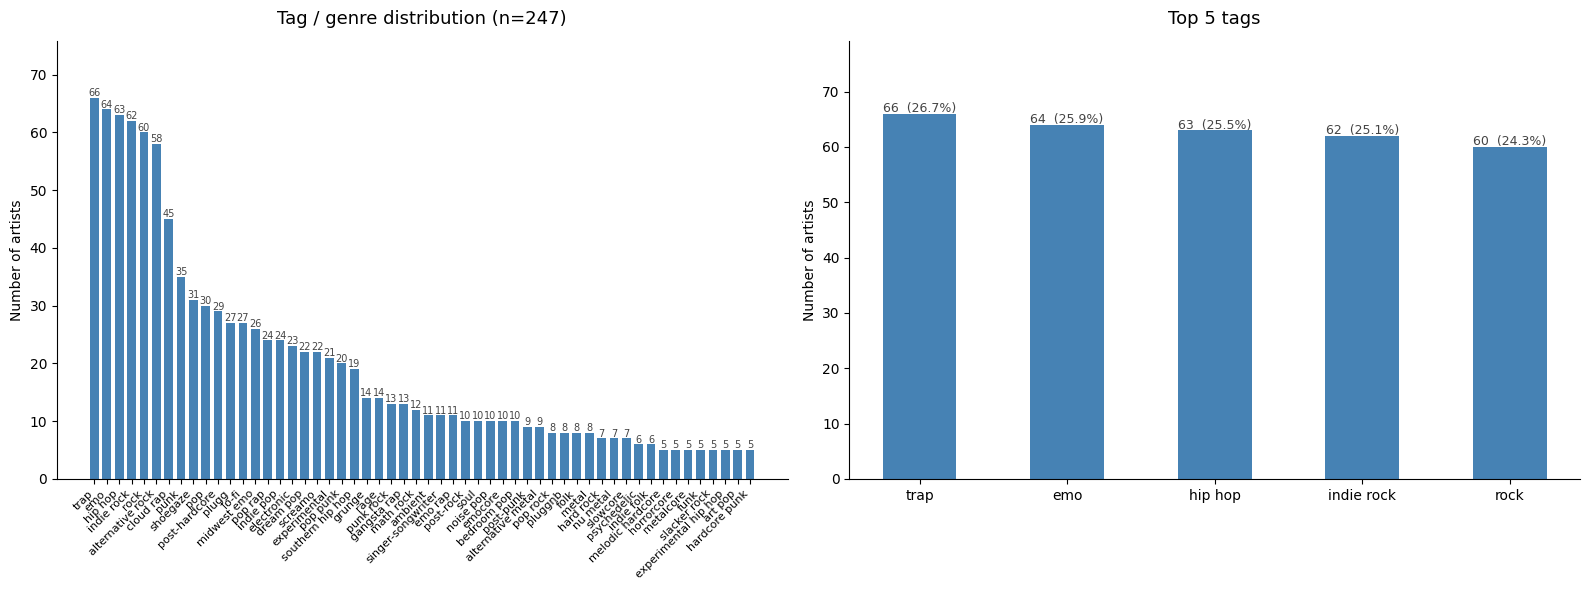

Top 5 exclusively indie rock artists by play count:
    artist_name  play_count
   wifiskeleton        1576
         Alex G        1244
Modern Baseball        1016
       Panchiko         791
       Marietta         710
Top 5 exclusively rock artists by play count:
                artist_name  play_count
                   Deftones        2712
                     Jaydes        2379
                    Nirvana        1625
        My Chemical Romance        1117
i wanna be a jack-o-lantern         561


In [136]:
tag_cols = final_df.columns.difference(['artist_name', 'play_count', 'url']).tolist()
tag_counts = final_df[tag_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# full distribution
bars = axes[0].bar(tag_counts.index, tag_counts.values, color='steelblue', edgecolor='none', width=0.7)
for bar, val in zip(bars, tag_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 str(val), ha='center', fontsize=7, color='#444')
axes[0].set_ylabel('Number of artists')
axes[0].set_title(f'Tag / genre distribution (n={len(final_df)})', fontsize=13, pad=12)
axes[0].set_xticks(range(len(tag_counts)))
axes[0].set_xticklabels(tag_counts.index, rotation=45, ha='right', fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim(0, tag_counts.max() * 1.15)

# top 5
top5 = tag_counts.head(5)
bars2 = axes[1].bar(top5.index, top5.values, color='steelblue', edgecolor='none', width=0.5)
for bar, val in zip(bars2, top5.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 f'{val}  ({val / len(final_df) * 100:.1f}%)',
                 ha='center', fontsize=9, color='#444')
axes[1].set_ylabel('Number of artists')
axes[1].set_title('Top 5 tags', fontsize=13, pad=12)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_ylim(0, top5.max() * 1.2)

plt.tight_layout()
plt.show()

# indie rock vs. rock genre
print('=' * 50)
print("Top 5 exclusively indie rock artists by play count:")
print(final_df[(final_df['indie rock'] == 1) & (final_df['rock'] == 0)].nlargest(5, 'play_count')[['artist_name', 'play_count']].to_string(index=False))

print('=' * 50)
print("Top 5 exclusively rock artists by play count:")
print(final_df[(final_df['rock'] == 1) & (final_df['indie rock'] == 0)].nlargest(5, 'play_count')[['artist_name', 'play_count']].to_string(index=False))

**Insights:**

- The genre distribution is heavily right skewed, with a set of 'broader' genres such as `trap`, `emo`, `hip hop`, `indie rock` and `rock` dominating.
- Genres such as `trap`, `emo`, and `indie rock` in LastFM aren't necessarily categorized as a more 'specific' genre / subgenre per se, nor are they necessarily part of any real hierarchy of genres or subgenres (i.e rock -> indie rock or hip hop -> trap).
    - In the case of `emo`, the genre has both been used to refer to both the original indie/punk subculture (Cap'n Jazz, Sunny Day Real Estate) and to the contemporary label applied to emotionally raw artists across hip hop, pop punk, and other genres (Lil Uzi Vert, Paramore, Panic! At The Disco).
    - Similarly, users most likely felt the `indie rock` tag to be a more apt description of artists that are closer both to independently produced music (Alex G, Panchiko) as well as the indie aesthetic (wifiskeleton) over the `rock` tag which usually implies mainstream acts such as Deftones, My Chemical Romance and Nirvana.
        - Worth noting is that the tags system is based on user-driven inputs, and then subsequently aggregated and weighted by how many users applied them.
        - As a result, tagging becomes inconsistent with heavy recency bias, prioritizing overall cultural consensus over accuracy (i.e Nirvana not being `indie rock` despite independent roots), and obscure artists resulting in a less reliable classified genre (i.e Jaydes and i wanna be a jack-o-lantern as `rock`).

## **Tag Count Per Artist**

## **Correlation**

## **Top Artists**